In [1]:
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import v2
from facenet_pytorch import InceptionResnetV1
from PIL import Image
from pathlib import Path
import numpy as np
import pandas as pd



dataset -> kaggle labelled faces in the wild (lfw) dataset, this already has the images pre-aligned and cropped to 250x250 pixels, which needs to be converted to 160x160 pixels.
* but using real world data would require additional steps to detect and align faces in the images before feeding them into the model, done using MTCNN.

model -> pre-trained FaceNet with inception resnet v1 architecture.


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
device

'cpu'

In [4]:
model = InceptionResnetV1(pretrained="vggface2").eval().to(device)

In [18]:
#we need to resize the image, convert to tensor and normalize it.
trasform = v2.Compose([
    v2.Resize((160,160)),
    v2.ToTensor(),
    v2.Normalize([0.5]*3, [0.5]*3)
])

e:\learning_pytorch\venv\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [6]:
a = Path("../../datasets/lfw-deepfunneled/lfw-deepfunneled/Aaron_Eckhart/Aaron_Eckhart_0001.jpg")
img = Image.open(a)
print(img.mode)

RGB


In [7]:
#image to embeddings
def img_to_emb(img_path):
    img = Image.open(img_path).convert("RGB")
    img = trasform(img).to(device)
    
    with torch.no_grad():
        emb = model(img.unsqueeze(0))
        
    return emb.cpu()

In [8]:
match_pairs_df = pd.read_csv("../../datasets/matchpairsDevTest.csv", header=0)
root_dir = Path("../../datasets/lfw-deepfunneled/lfw-deepfunneled")

In [9]:
match_pairs_df.tail(5)

,name,imagenum1,imagenum2
495,Winona_Ryder,6,15
496,Winona_Ryder,19,21
497,Yevgeny_Kafelnikov,3,4
498,Yoriko_Kawaguchi,3,10
499,Zoran_Djindjic,3,4


In [10]:
def get_img_path(name, index):
    p = root_dir/ name / f"{name}_{index:04d}.jpg"
    return p

In [11]:
def match_pairs_devtrain(match_pairs_df):
    pairs = []
    for _, row in match_pairs_df.iterrows():
        name = row.iloc[0]
        index1 = int(row.iloc[1])
        index2 = int(row.iloc[2])
        img1 = get_img_path(name, index1)
        img2 = get_img_path(name, index2)
        pairs.append((img1, img2))
        
    return pairs
        

In [12]:
pairs = match_pairs_devtrain(match_pairs_df)
print("total pairs:", len(pairs))
print(pairs[:3])

total pairs: 500
[(WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Abdullah_Gul/Abdullah_Gul_0013.jpg'), WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Abdullah_Gul/Abdullah_Gul_0014.jpg')), (WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Abdullah_Gul/Abdullah_Gul_0013.jpg'), WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Abdullah_Gul/Abdullah_Gul_0016.jpg')), (WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Abdullatif_Sener/Abdullatif_Sener_0001.jpg'), WindowsPath('../../datasets/lfw-deepfunneled/lfw-deepfunneled/Abdullatif_Sener/Abdullatif_Sener_0002.jpg'))]


In [23]:
def evaluate_dataset(pairs, threshold = 1):
    correct = 0
    incorrect = 0
    total = 0
    print("generating embeddings: ")
    for img1_pth, img2_pth in pairs:
        emb1 = img_to_emb(img1_pth)
        emb2 = img_to_emb(img2_pth)
        dist = torch.norm(emb1 - emb2).item()
        pred = 1 if dist < threshold else 0
        if pred == 1:
            correct += 1
            
        else:
            incorrect += 1
            
        total += 1
    
    acc = correct/total
    print("total correct : ", correct)
    print("incorrect : ", incorrect)
    print("accuracy : ",acc)
    return acc
    

In [21]:
evaluate_dataset(pairs)

generating embeddings: 
total correct :  447
incorrect :  53
accuracy :  0.894


generating embeddings: 
total correct :  25
incorrect :  475
accuracy :  0.05
generating embeddings: 
total correct :  40
incorrect :  460
accuracy :  0.08
generating embeddings: 
total correct :  69
incorrect :  431
accuracy :  0.138
generating embeddings: 
total correct :  108
incorrect :  392
accuracy :  0.216
generating embeddings: 
total correct :  167
incorrect :  333
accuracy :  0.334
generating embeddings: 
total correct :  225
incorrect :  275
accuracy :  0.45
generating embeddings: 
total correct :  285
incorrect :  215
accuracy :  0.57
generating embeddings: 
total correct :  336
incorrect :  164
accuracy :  0.672
generating embeddings: 
total correct :  382
incorrect :  118
accuracy :  0.764
generating embeddings: 
total correct :  414
incorrect :  86
accuracy :  0.828
generating embeddings: 
total correct :  447
incorrect :  53
accuracy :  0.894
generating embeddings: 
total correct :  471
incorrect :  29
accuracy :  0.942
generating embeddings: 
total correct :  480
incor

Text(0.5, 1.0, 'accuracy vs threshold')

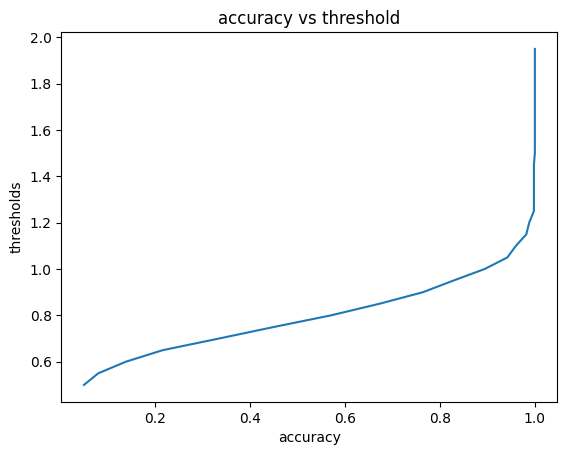

In [ ]:
accuracy = []
acc = 0
thresholds = np.arange(0.5, 2.0, 0.05)
for threshold in thresholds:
    print("for threshold = ", threshold)
    acc = evaluate_dataset(pairs, threshold)
    accuracy.append(acc)
    

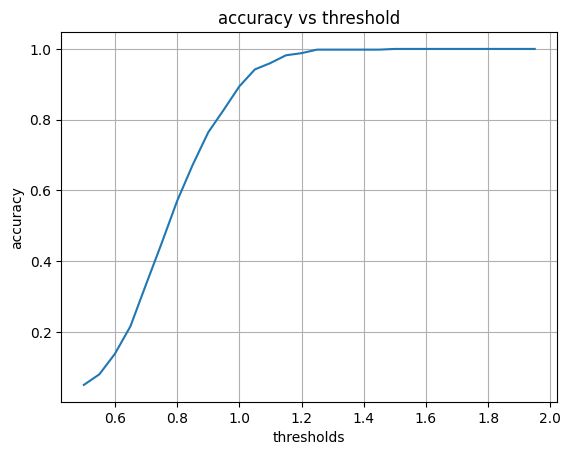

In [28]:
plt.plot(thresholds, accuracy)
plt.ylabel("accuracy")
plt.xlabel("thresholds")
plt.title("accuracy vs threshold")
plt.grid(True)

In [ ]:
#now i know the pipeline, i will evaluate the model properly